### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [1]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.24.2.


In [2]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

In [3]:
!python -m pip install --upgrade scikit-learn
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

Requirement already up-to-date: scikit-learn in /opt/conda/lib/python3.6/site-packages (0.24.2)
The scikit-learn version is 0.24.2.


In [50]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

In [5]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [6]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [7]:
# Load in the general demographics data.

azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')

# Load in the feature summary file.

feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [8]:
# Check the structure of the data after it's loaded
# (e.g. print the number of rows and columns, print the first few rows).

print("AZDIAS shape:", azdias.shape)
print("Feature summary shape:", feat_info.shape)

display(azdias.head())
display(feat_info.head())

AZDIAS shape: (891221, 85)
Feature summary shape: (85, 4)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [9]:
# Identify missing or unknown data values and convert them to NaNs.

for idx, row in feat_info.iterrows():
    attribute = row['attribute']
    
    # Parse the missing/unknown codes from the feature summary
    missing_codes = row['missing_or_unknown']
    missing_codes = missing_codes.strip('[]').split(',')
    
    parsed_codes = []
    
    for code in missing_codes:
        code = code.strip()
        
        try:
            parsed_codes.append(int(code))
        except ValueError:
            parsed_codes.append(code)
    
    # Replace missing/unknown codes with NaN
    azdias[attribute] = azdias[attribute].replace(parsed_codes, np.nan)

print("Missing values after conversion:", azdias.isnull().sum().sum())

Missing values after conversion: 8373929


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [10]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

missing_count = azdias.isnull().sum()
missing_percent = (missing_count / len(azdias)) * 100

missing_by_column = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_by_column.sort_values(
    'missing_percent',
    ascending=False
).head(20)

,missing_count,missing_percent
TITEL_KZ,889061,99.757636
AGER_TYP,685843,76.955435
KK_KUNDENTYP,584612,65.596749
KBA05_BAUMAX,476524,53.468668
GEBURTSJAHR,392318,44.020282
ALTER_HH,310267,34.813699
KKK,158064,17.735668
REGIOTYP,158064,17.735668
W_KEIT_KIND_HH,147988,16.605084
KBA05_ANTG1,133324,14.959701


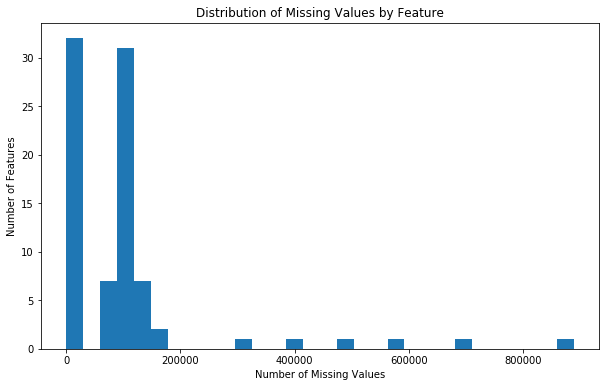

,missing_count,missing_percent
TITEL_KZ,889061,99.757636
AGER_TYP,685843,76.955435
KK_KUNDENTYP,584612,65.596749
KBA05_BAUMAX,476524,53.468668
GEBURTSJAHR,392318,44.020282
ALTER_HH,310267,34.813699


In [11]:
# Investigate patterns in the amount of missing data in each column.

plt.figure(figsize=(10, 6))
plt.hist(missing_count, bins=30)

plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Features')
plt.title('Distribution of Missing Values by Feature')

plt.show()

# Display columns with more than 20% missing data
missing_by_column[
    missing_by_column['missing_percent'] > 20
].sort_values(
    'missing_percent',
    ascending=False
)

In [12]:
# Remove the outlier columns from the dataset.

outlier_columns = [
    'TITEL_KZ',
    'AGER_TYP',
    'KK_KUNDENTYP',
    'KBA05_BAUMAX',
    'GEBURTSJAHR',
    'ALTER_HH'
]

azdias.drop(
    columns=outlier_columns,
    inplace=True,
    errors='ignore'
)

print("Dataset shape after removing outlier columns:", azdias.shape)

Dataset shape after removing outlier columns: (891221, 79)


#### Discussion 1.1.2: Assess Missing Data in Each Column

<p>
The amount of missing data varied considerably across the features. Most columns had relatively low levels of missing data, but six columns stood out with much higher missing percentages.
</p>

<p>
The columns removed were <code>TITEL_KZ</code>, <code>AGER_TYP</code>, <code>KK_KUNDENTYP</code>, <code>KBA05_BAUMAX</code>, <code>GEBURTSJAHR</code>, and <code>ALTER_HH</code>. Their missing values ranged from approximately 35% to almost 100% of the dataset. I removed these features because the amount of missing information was much greater than for the remaining columns.
</p>

<p>
There were also groups of features with similar missing-value counts. This suggests that some missing data may be associated with related demographic or geographic information rather than occurring independently across every feature. The remaining columns were retained for further preprocessing.
</p>

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

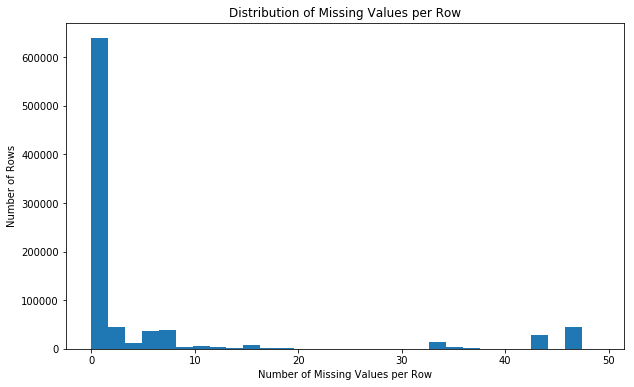

count    891221.000000
mean          5.649894
std          13.234687
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max          49.000000
dtype: float64

In [13]:
# How much data is missing in each row of the dataset?

missing_by_row = azdias.isnull().sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(missing_by_row, bins=30)

plt.xlabel('Number of Missing Values per Row')
plt.ylabel('Number of Rows')
plt.title('Distribution of Missing Values per Row')

plt.show()

missing_by_row.describe()

In [14]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

threshold = 20

# No .copy() here because these subsets are only being used for comparison
azdias_low_missing = azdias.loc[missing_by_row <= threshold]
azdias_high_missing = azdias.loc[missing_by_row > threshold]

print(
    "Rows with 20 or fewer missing values:",
    azdias_low_missing.shape[0]
)

print(
    "Rows with more than 20 missing values:",
    azdias_high_missing.shape[0]
)

Rows with 20 or fewer missing values: 797426
Rows with more than 20 missing values: 93795


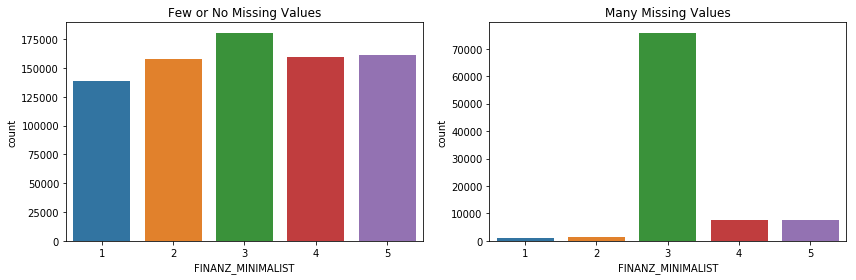

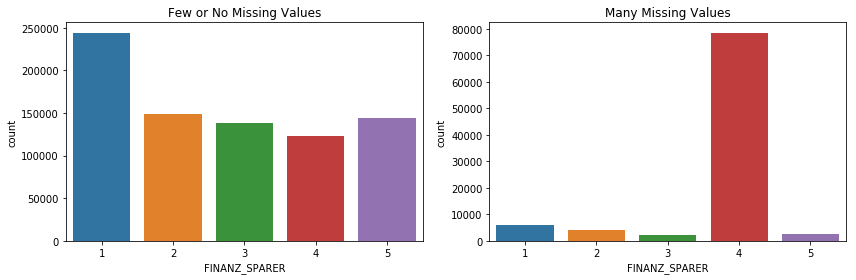

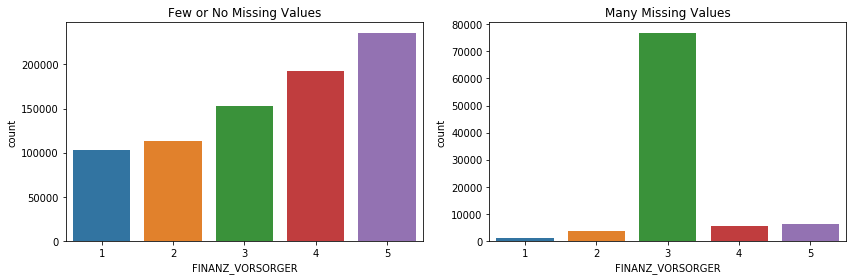

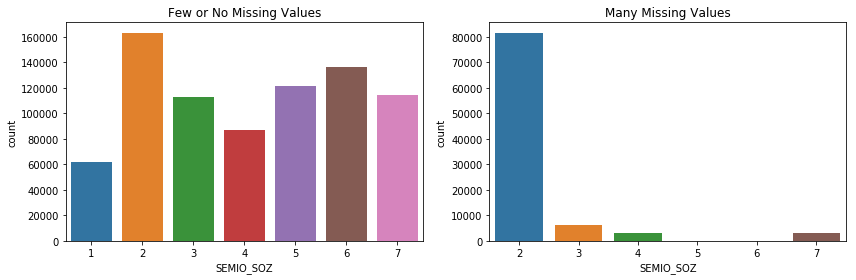

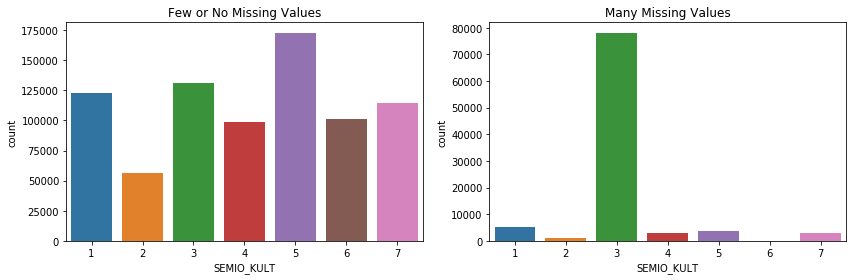

In [15]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

columns_to_compare = [
    'FINANZ_MINIMALIST',
    'FINANZ_SPARER',
    'FINANZ_VORSORGER',
    'SEMIO_SOZ',
    'SEMIO_KULT'
]

def compare_distributions(column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(
        x=column,
        data=azdias_low_missing,
        ax=axes[0]
    )
    axes[0].set_title('Few or No Missing Values')

    sns.countplot(
        x=column,
        data=azdias_high_missing,
        ax=axes[1]
    )
    axes[1].set_title('Many Missing Values')

    plt.tight_layout()
    plt.show()


for column in columns_to_compare:
    compare_distributions(column)

In [16]:
# Continue the analysis using only rows with 20 or fewer missing values.

azdias.drop(
    index=azdias.index[missing_by_row > threshold],
    inplace=True
)

# Remove temporary objects that are no longer needed
del azdias_low_missing
del azdias_high_missing
del missing_by_row

import gc
gc.collect()

print("Dataset shape after removing high-missing rows:", azdias.shape)

Dataset shape after removing high-missing rows: (797426, 79)


#### Discussion 1.1.3: Assess Missing Data in Each Row

<p>
The number of missing values per row was unevenly distributed. Most rows contained very little missing data. The median was 0 missing values, and 75% of the rows had 3 or fewer missing values. A smaller group contained much larger amounts of missing data, with some rows missing as many as 49 values.
</p>

<p>
I used 20 missing values as the cutoff between the two groups. This produced 797,426 rows with 20 or fewer missing values and 93,795 rows with more than 20 missing values.
</p>

<p>
Comparing several features between the two groups showed noticeable differences in their value distributions. The rows with high missingness are not simply a random sample of the remaining population and appear qualitatively different. I removed these rows from the data used for the main analysis, as instructed, but this difference should be considered when interpreting the results.
</p>

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [17]:
# How many features are there of each data type?

feature_type_counts = feat_info['type'].value_counts()

print(feature_type_counts)

ordinal        49
categorical    21
numeric         7
mixed           7
interval        1
Name: type, dtype: int64


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [18]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

categorical_features = feat_info[
    feat_info['type'] == 'categorical'
]['attribute'].tolist()

# Only include columns that are still present after earlier cleaning
categorical_features = [
    col for col in categorical_features
    if col in azdias.columns
]

binary_categorical = []
multi_categorical = []

for column in categorical_features:
    num_levels = azdias[column].nunique(dropna=True)

    if num_levels == 2:
        binary_categorical.append(column)
    elif num_levels > 2:
        multi_categorical.append(column)

print("Binary categorical features:")
print(binary_categorical)

print("\nMulti-level categorical features:")
print(multi_categorical)

print("\nBinary feature values:")
for column in binary_categorical:
    print(column, azdias[column].dropna().unique())

Binary categorical features:
['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'VERS_TYP', 'OST_WEST_KZ']

Multi-level categorical features:
['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']

Binary feature values:
ANREDE_KZ [2 1]
GREEN_AVANTGARDE [0 1]
SOHO_KZ [1. 0.]
VERS_TYP [2. 1.]
OST_WEST_KZ ['W' 'O']


In [19]:
# Re-encode categorical variable(s) to be kept in the analysis.

# Convert the non-numeric binary feature to numeric values.
# Using replace instead of map makes this safe if the cell is run more than once.
azdias['OST_WEST_KZ'] = azdias['OST_WEST_KZ'].replace({
    'W': 1,
    'O': 0
})

# One-hot encode multi-level categorical features.
azdias = pd.get_dummies(
    azdias,
    columns=multi_categorical
)

print("Dataset shape after categorical encoding:", azdias.shape)

print(
    "Non-numeric columns remaining:",
    azdias.select_dtypes(exclude=[np.number]).columns.tolist()
)

Dataset shape after categorical encoding: (797426, 194)
Non-numeric columns remaining: ['CAMEO_INTL_2015']


#### Discussion 1.2.1: Re-Encode Categorical Features

<p>
The categorical features were separated into binary and multi-level variables. The binary features were <code>ANREDE_KZ</code>, <code>GREEN_AVANTGARDE</code>, <code>SOHO_KZ</code>, <code>VERS_TYP</code>, and <code>OST_WEST_KZ</code>.
</p>

<p>
The numeric binary features were retained without additional encoding. <code>OST_WEST_KZ</code> contained the non-numeric values <code>W</code> and <code>O</code>, so I converted these values to 1 and 0.
</p>

<p>
The multi-level categorical features were retained and converted into dummy variables using <code>pd.get_dummies()</code>. This allows each category to be represented numerically without treating the original category codes as ordered measurements. No multi-level categorical features were dropped during this step.
</p>

<p>
After categorical encoding, the dataset contained 194 columns. The remaining non-numeric feature, <code>CAMEO_INTL_2015</code>, is a mixed-type feature and will be handled separately in the mixed-feature engineering step.
</p>

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [20]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.

# Map each code to its decade
decade_map = {
    1: 40, 2: 40,
    3: 50, 4: 50,
    5: 60, 6: 60, 7: 60,
    8: 70, 9: 70,
    10: 80, 11: 80, 12: 80, 13: 80,
    14: 90, 15: 90
}

# Codes representing avantgarde movement
avantgarde_codes = [2, 4, 6, 7, 9, 11, 13, 15]

azdias['PRAEGENDE_DECADE'] = (
    azdias['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
)

azdias['PRAEGENDE_MOVEMENT'] = (
    azdias['PRAEGENDE_JUGENDJAHRE'].apply(
        lambda x: 1 if x in avantgarde_codes
        else (0 if pd.notnull(x) else np.nan)
    )
)

# Original feature is no longer needed
azdias.drop(
    columns=['PRAEGENDE_JUGENDJAHRE'],
    inplace=True
)

print(
    azdias[['PRAEGENDE_DECADE', 'PRAEGENDE_MOVEMENT']].head()
)

   PRAEGENDE_DECADE  PRAEGENDE_MOVEMENT
1              90.0                 0.0
2              90.0                 1.0
3              70.0                 0.0
4              70.0                 0.0
5              50.0                 0.0


In [21]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

azdias['CAMEO_WEALTH'] = azdias['CAMEO_INTL_2015'].apply(
    lambda x: int(str(x)[0]) if pd.notnull(x) else np.nan
)

azdias['CAMEO_LIFESTAGE'] = azdias['CAMEO_INTL_2015'].apply(
    lambda x: int(str(x)[1]) if pd.notnull(x) else np.nan
)

# Original feature is no longer needed
azdias.drop(
    columns=['CAMEO_INTL_2015'],
    inplace=True
)

print(
    azdias[['CAMEO_WEALTH', 'CAMEO_LIFESTAGE']].head()
)

   CAMEO_WEALTH  CAMEO_LIFESTAGE
1           5.0              1.0
2           2.0              4.0
3           1.0              2.0
4           4.0              3.0
5           5.0              4.0


In [22]:
# Drop remaining mixed-type features.

remaining_mixed = [
    'LP_LEBENSPHASE_FEIN',
    'LP_LEBENSPHASE_GROB',
    'WOHNLAGE',
    'PLZ8_BAUMAX'
]

azdias.drop(
    columns=remaining_mixed,
    inplace=True,
    errors='ignore'
)

print("Dataset shape after mixed-feature processing:", azdias.shape)

Dataset shape after mixed-feature processing: (797426, 192)


#### Discussion 1.2.2: Engineer Mixed-Type Features

<p>
I engineered the two mixed-type features identified for special treatment. <code>PRAEGENDE_JUGENDJAHRE</code> was separated into <code>PRAEGENDE_DECADE</code>, which represents the person's generation by decade, and <code>PRAEGENDE_MOVEMENT</code>, which identifies mainstream or avantgarde movement membership. The original <code>PRAEGENDE_JUGENDJAHRE</code> column was then removed.
</p>

<p>
I separated <code>CAMEO_INTL_2015</code> into <code>CAMEO_WEALTH</code> and <code>CAMEO_LIFESTAGE</code>. The first digit of the original two-digit value represents wealth, and the second digit represents life stage. The original <code>CAMEO_INTL_2015</code> column was removed after creating these features.
</p>

<p>
The remaining mixed features, <code>LP_LEBENSPHASE_FEIN</code>, <code>LP_LEBENSPHASE_GROB</code>, <code>WOHNLAGE</code>, and <code>PLZ8_BAUMAX</code>, were dropped rather than further re-encoded. After mixed-feature processing, the dataset contained 192 features.
</p>

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [23]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

original_mixed_features = [
    'PRAEGENDE_JUGENDJAHRE',
    'CAMEO_INTL_2015',
    'LP_LEBENSPHASE_FEIN',
    'LP_LEBENSPHASE_GROB',
    'WOHNLAGE',
    'PLZ8_BAUMAX'
]

remaining_original_mixed = [
    col for col in original_mixed_features
    if col in azdias.columns
]

print("Original mixed features still present:", remaining_original_mixed)

Original mixed features still present: []


In [24]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

non_numeric_columns = azdias.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Non-numeric columns remaining:", non_numeric_columns)
print("Final dataset shape:", azdias.shape)

Non-numeric columns remaining: []
Final dataset shape: (797426, 192)


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [44]:
def clean_data(df):
    """
    Perform feature trimming, re-encoding, and engineering for demographics data.

    INPUT:
        df - Demographics DataFrame

    OUTPUT:
        Trimmed and cleaned demographics DataFrame
    """

    df = df.copy()

    # Convert missing/unknown value codes to NaN
    for idx, row in feat_info.iterrows():
        attribute = row['attribute']

        if attribute not in df.columns:
            continue

        missing_codes = row['missing_or_unknown']
        missing_codes = missing_codes.strip('[]').split(',')

        parsed_codes = []

        for code in missing_codes:
            code = code.strip()

            try:
                parsed_codes.append(int(code))
            except ValueError:
                parsed_codes.append(code)

        df[attribute] = df[attribute].replace(
            parsed_codes,
            np.nan
        )

    # Remove columns with excessive missing data
    outlier_columns = [
        'TITEL_KZ',
        'AGER_TYP',
        'KK_KUNDENTYP',
        'KBA05_BAUMAX',
        'GEBURTSJAHR',
        'ALTER_HH'
    ]

    df.drop(
        columns=outlier_columns,
        inplace=True,
        errors='ignore'
    )

    # Remove rows with more than 20 missing values
    row_missing = df.isnull().sum(axis=1)

    df.drop(
        index=df.index[row_missing > 20],
        inplace=True
    )

    # Re-encode OST_WEST_KZ
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].replace({
            'W': 1,
            'O': 0
        })

    # One-hot encode multi-level categorical features
    multi_categorical = [
        'CJT_GESAMTTYP',
        'FINANZTYP',
        'GFK_URLAUBERTYP',
        'LP_FAMILIE_FEIN',
        'LP_FAMILIE_GROB',
        'LP_STATUS_FEIN',
        'LP_STATUS_GROB',
        'NATIONALITAET_KZ',
        'SHOPPER_TYP',
        'ZABEOTYP',
        'GEBAEUDETYP',
        'CAMEO_DEUG_2015',
        'CAMEO_DEU_2015'
    ]

    multi_categorical = [
        col for col in multi_categorical
        if col in df.columns
    ]

    df = pd.get_dummies(
        df,
        columns=multi_categorical
    )

    # Engineer PRAEGENDE_JUGENDJAHRE
    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:

        decade_map = {
            1: 40, 2: 40,
            3: 50, 4: 50,
            5: 60, 6: 60, 7: 60,
            8: 70, 9: 70,
            10: 80, 11: 80, 12: 80, 13: 80,
            14: 90, 15: 90
        }

        avantgarde_codes = [
            2, 4, 6, 7, 9, 11, 13, 15
        ]

        df['PRAEGENDE_DECADE'] = (
            df['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        )

        df['PRAEGENDE_MOVEMENT'] = (
            df['PRAEGENDE_JUGENDJAHRE'].apply(
                lambda x: 1 if x in avantgarde_codes
                else (0 if pd.notnull(x) else np.nan)
            )
        )

        df.drop(
            columns=['PRAEGENDE_JUGENDJAHRE'],
            inplace=True
        )

    # Engineer CAMEO_INTL_2015
    if 'CAMEO_INTL_2015' in df.columns:

        df['CAMEO_WEALTH'] = (
            df['CAMEO_INTL_2015'].apply(
                lambda x: int(str(x)[0])
                if pd.notnull(x)
                else np.nan
            )
        )

        df['CAMEO_LIFESTAGE'] = (
            df['CAMEO_INTL_2015'].apply(
                lambda x: int(str(x)[1])
                if pd.notnull(x)
                else np.nan
            )
        )

        df.drop(
            columns=['CAMEO_INTL_2015'],
            inplace=True
        )

    # Drop remaining mixed features
    remaining_mixed = [
        'LP_LEBENSPHASE_FEIN',
        'LP_LEBENSPHASE_GROB',
        'WOHNLAGE',
        'PLZ8_BAUMAX'
    ]

    df.drop(
        columns=remaining_mixed,
        inplace=True,
        errors='ignore'
    )

    # Match the exact feature set and order used for the population data
    df = df.reindex(
        columns=feature_columns,
        fill_value=0
    )

    return df

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [26]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

from sklearn.impute import SimpleImputer

print("Remaining NaN values:", azdias.isnull().sum().sum())

# Save the feature order for the customer dataset later
feature_columns = azdias.columns.tolist()

# Convert the dataframe to float32 before imputation to reduce memory use
azdias = azdias.astype(np.float32)

imputer = SimpleImputer(strategy='median')

# Impute the missing values
azdias_array = imputer.fit_transform(azdias)

# Keep the smaller float32 datatype
azdias_array = azdias_array.astype(np.float32, copy=False)

print("NaN values after imputation:", np.isnan(azdias_array).sum())
print("Imputed data shape:", azdias_array.shape)
print("Data type:", azdias_array.dtype)

Remaining NaN values: 751879
NaN values after imputation: 0
Imputed data shape: (797426, 192)
Data type: float32


In [27]:
# Apply feature scaling to the general population demographics data.

from sklearn.preprocessing import StandardScaler
import gc

# The pandas dataframe is no longer needed for model fitting
del azdias
gc.collect()

scaler = StandardScaler(copy=False)

azdias_scaled = scaler.fit_transform(azdias_array)

print("Scaled data shape:", azdias_scaled.shape)
print("Approximate mean:", azdias_scaled.mean())
print("Approximate standard deviation:", azdias_scaled.std())

Scaled data shape: (797426, 192)
Approximate mean: -3.242993e-09
Approximate standard deviation: 0.9999984


In [28]:
print("Features before imputation:", len(feature_columns))
print("Features after imputation:", azdias_array.shape[1])

all_nan_columns = [
    feature_columns[i]
    for i in range(len(feature_columns))
    if imputer.statistics_[i] != imputer.statistics_[i]
]

print("All-NaN columns dropped by imputer:", all_nan_columns)

Features before imputation: 192
Features after imputation: 192
All-NaN columns dropped by imputer: []


### Discussion 2.1: Apply Feature Scaling

<p>
After preprocessing, the dataset still contained missing values. I used median imputation to replace the remaining missing values. Median imputation was selected because it allows the rows retained during preprocessing to remain in the analysis and is less affected by extreme values than mean imputation. After imputation, no missing values remained, and all 192 features were retained.
</p>

<p>
I then applied StandardScaler to standardize the features. This produced features centered near a mean of 0 with a standard deviation near 1. Scaling was necessary because the features use different numeric ranges, and PCA could otherwise give greater weight to features with larger numerical scales.
</p>

<p>
The fitted imputer and scaler were retained so the same transformations can be applied to the customer dataset later in the analysis.
</p>

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [29]:
from sklearn.decomposition import PCA

# Apply PCA to the data.
# Use at least half of the 192 features for the initial variance check.

pca = PCA(
    n_components=96,
    svd_solver='randomized',
    random_state=42
)

pca.fit(azdias_scaled)

print("PCA fitted successfully.")
print("Components fitted:", pca.n_components_)

PCA fitted successfully.
Components fitted: 96


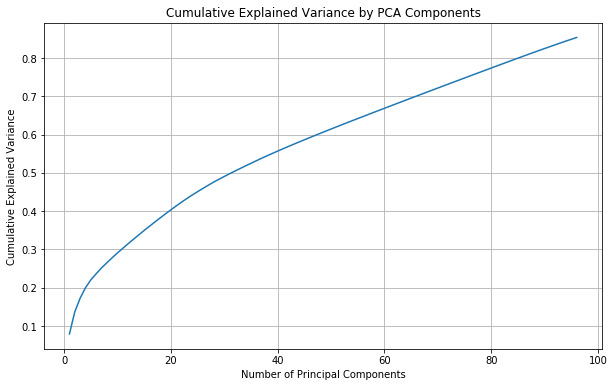

20 components: 40.34 % variance explained
40 components: 55.68 % variance explained
60 components: 66.87 % variance explained
80 components: 77.39 % variance explained
96 components: 85.37 % variance explained


In [30]:
# Investigate the variance accounted for by each principal component.

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid()

plt.show()

for n in [20, 40, 60, 80, 96]:
    print(
        n,
        "components:",
        round(cumulative_variance[n - 1] * 100, 2),
        "% variance explained"
    )

In [31]:
# Re-apply PCA to the data while selecting for number of components to retain.

# Retain 80 components, which explain about 77.39% of the variance.
n_components = 80

pca_final = PCA(
    n_components=n_components,
    svd_solver='randomized',
    random_state=42
)

azdias_pca = pca_final.fit_transform(azdias_scaled)

# Keep the transformed matrix memory-efficient
azdias_pca = azdias_pca.astype(np.float32, copy=False)

print("Reduced PCA shape:", azdias_pca.shape)
print(
    "Total variance retained:",
    round(pca_final.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Reduced PCA shape: (797426, 80)
Total variance retained: 77.11 %


### Discussion 2.2: Perform Dimensionality Reduction

<p>
I applied PCA to the standardized demographic data and examined the cumulative explained variance as the number of principal components increased. The initial PCA analysis showed that 20 components explained 40.34% of the variance, 40 explained 55.68%, 60 explained 66.87%, and 80 explained about 77% of the variance.
</p>

<p>
I selected 80 principal components for the remaining analysis. After fitting the final PCA model with 80 components, the transformed dataset retained 77.11% of the total variance. This reduced the dataset from 192 features to 80 transformed features while retaining a substantial amount of the information in the original data.
</p>

<p>
The 80-component PCA model will be used for the clustering analysis and later applied to the customer dataset.
</p>

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [32]:
# Map PCA weights to their corresponding feature names.

def pca_weights(pca, component_num, feature_names):
    weights = pd.DataFrame({
        'feature': feature_names,
        'weight': pca.components_[component_num]
    })

    return weights.sort_values(
        by='weight',
        ascending=False
    ).reset_index(drop=True)


# First principal component
pc1_weights = pca_weights(
    pca_final,
    0,
    feature_columns
)

print("Principal Component 1")
print("\nHighest positive weights:")
print(pc1_weights.head(10))

print("\nHighest negative weights:")
print(pc1_weights.tail(10))

Principal Component 1

Highest positive weights:
              feature    weight
0  LP_STATUS_GROB_1.0  0.196791
1  HH_EINKOMMEN_SCORE  0.186739
2        CAMEO_WEALTH  0.186282
3          PLZ8_ANTG3  0.181756
4          PLZ8_ANTG4  0.175890
5         ORTSGR_KLS9  0.154900
6            EWDICHTE  0.153601
7    FINANZ_HAUSBAUER  0.149592
8         KBA05_ANTG4  0.130280
9  LP_STATUS_FEIN_1.0  0.127682

Highest negative weights:
                 feature    weight
182  LP_STATUS_FEIN_10.0 -0.115255
183   LP_STATUS_GROB_5.0 -0.115255
184           INNENSTADT -0.127558
185             PLZ8_GBZ -0.133266
186          KONSUMNAEHE -0.136756
187            KBA05_GBZ -0.181444
188           PLZ8_ANTG1 -0.182832
189          KBA05_ANTG1 -0.189383
190    FINANZ_MINIMALIST -0.192486
191           MOBI_REGIO -0.205558


In [33]:
# Map weights for the second principal component to corresponding feature names.

pc2_weights = pca_weights(
    pca_final,
    1,
    feature_columns
)

print("Principal Component 2")
print("\nHighest positive weights:")
print(pc2_weights.head(10))

print("\nHighest negative weights:")
print(pc2_weights.tail(10))

Principal Component 2

Highest positive weights:
                feature    weight
0  ALTERSKATEGORIE_GROB  0.233052
1      FINANZ_VORSORGER  0.218911
2            ZABEOTYP_3  0.200482
3             SEMIO_ERL  0.180364
4            SEMIO_LUST  0.163954
5        RETOURTYP_BK_S  0.155974
6        W_KEIT_KIND_HH  0.128202
7     CJT_GESAMTTYP_2.0  0.108202
8           FINANZTYP_5  0.097960
9    LP_STATUS_FEIN_1.0  0.097269

Highest negative weights:
                   feature    weight
182      ONLINE_AFFINITAET -0.162937
183             SEMIO_KULT -0.164759
184              SEMIO_RAT -0.168026
185         FINANZ_ANLEGER -0.203110
186          SEMIO_PFLICHT -0.204712
187            SEMIO_TRADV -0.208184
188              SEMIO_REL -0.213655
189  FINANZ_UNAUFFAELLIGER -0.215188
190          FINANZ_SPARER -0.226405
191       PRAEGENDE_DECADE -0.238202


In [34]:
# Map weights for the third principal component to corresponding feature names.

pc3_weights = pca_weights(
    pca_final,
    2,
    feature_columns
)

print("Principal Component 3")
print("\nHighest positive weights:")
print(pc3_weights.head(10))

print("\nHighest negative weights:")
print(pc3_weights.tail(10))

Principal Component 3

Highest positive weights:
             feature    weight
0         SEMIO_VERT  0.318877
1          SEMIO_FAM  0.260597
2          SEMIO_SOZ  0.256968
3         SEMIO_KULT  0.251499
4        FINANZTYP_5  0.135140
5  FINANZ_MINIMALIST  0.128929
6    SHOPPER_TYP_0.0  0.122642
7         ZABEOTYP_1  0.116555
8          SEMIO_REL  0.113089
9          SEMIO_MAT  0.089274

Highest negative weights:
                feature    weight
182  LP_STATUS_FEIN_2.0 -0.079439
183     SHOPPER_TYP_2.0 -0.092978
184         FINANZTYP_1 -0.100371
185      FINANZ_ANLEGER -0.153344
186           SEMIO_RAT -0.154662
187           SEMIO_ERL -0.208008
188          SEMIO_KRIT -0.266863
189           SEMIO_DOM -0.283801
190          SEMIO_KAEM -0.315227
191           ANREDE_KZ -0.345061


### Discussion 2.3: Interpret Principal Components

<p>
The first three principal components show meaningful relationships among the original demographic features. Principal Component 1 appears to represent socioeconomic status and residential characteristics. Its strongest positive weights include <code>LP_STATUS_GROB_1.0</code>, <code>HH_EINKOMMEN_SCORE</code>, <code>CAMEO_WEALTH</code>, <code>PLZ8_ANTG3</code>, and <code>PLZ8_ANTG4</code>. Strong negative weights include <code>MOBI_REGIO</code>, <code>FINANZ_MINIMALIST</code>, <code>KBA05_ANTG1</code>, and <code>PLZ8_ANTG1</code>. Higher PC1 values are associated with greater wealth and higher socioeconomic status, whereas lower values are associated with financial minimalism and residential areas containing more small buildings.
</p>

<p>
Principal Component 2 appears to separate age and financial or lifestyle characteristics. <code>ALTERSKATEGORIE_GROB</code>, <code>FINANZ_VORSORGER</code>, <code>SEMIO_ERL</code>, and <code>SEMIO_LUST</code> have strong positive weights. <code>PRAEGENDE_DECADE</code>, <code>FINANZ_SPARER</code>, <code>FINANZ_UNAUFFAELLIGER</code>, <code>SEMIO_REL</code>, and <code>FINANZ_ANLEGER</code> have strong negative weights. This suggests that positive and negative PC2 scores distinguish different age groups along with differences in saving, investing, and personal characteristics.
</p>

<p>
Principal Component 3 is strongly associated with personality characteristics and gender coding. Its strongest positive weights include <code>SEMIO_VERT</code>, <code>SEMIO_FAM</code>, <code>SEMIO_SOZ</code>, and <code>SEMIO_KULT</code>. Its strongest negative weights include <code>ANREDE_KZ</code>, <code>SEMIO_KAEM</code>, <code>SEMIO_DOM</code>, <code>SEMIO_KRIT</code>, and <code>SEMIO_ERL</code>. These opposing weights indicate that PC3 separates groups based largely on these personality and demographic characteristics.
</p>

<p>
The positive and negative component values can be interpreted meaningfully because features with weights of the same sign tend to contribute in the same direction, whereas features with opposite signs contribute in opposing directions. The first three components capture distinct combinations of socioeconomic, age, financial, residential, and personality characteristics.
</p>

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [35]:
from sklearn.cluster import KMeans

# Use a reproducible sample to compare cluster counts.
np.random.seed(42)

# Smaller sample keeps KMeans manageable in the Udacity workspace.
sample_size = 50000

sample_indices = np.random.choice(
    azdias_pca.shape[0],
    size=sample_size,
    replace=False
)

pca_sample = azdias_pca[sample_indices]

# Test 2 through 10 clusters.
cluster_counts = range(2, 11)
avg_distances = []

for k in cluster_counts:

    print("Starting", k, "clusters...")

    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        max_iter=100
    )

    kmeans_test.fit(pca_sample)

    avg_distance = (
        kmeans_test.inertia_ / pca_sample.shape[0]
    )

    avg_distances.append(avg_distance)

    print(
        "Clusters:",
        k,
        "| Average within-cluster distance:",
        round(avg_distance, 2)
    )

Starting 2 clusters...
Clusters: 2 | Average within-cluster distance: 135.97
Starting 3 clusters...
Clusters: 3 | Average within-cluster distance: 130.4
Starting 4 clusters...
Clusters: 4 | Average within-cluster distance: 126.72
Starting 5 clusters...
Clusters: 5 | Average within-cluster distance: 124.91
Starting 6 clusters...
Clusters: 6 | Average within-cluster distance: 122.09
Starting 7 clusters...
Clusters: 7 | Average within-cluster distance: 120.33
Starting 8 clusters...
Clusters: 8 | Average within-cluster distance: 118.46
Starting 9 clusters...
Clusters: 9 | Average within-cluster distance: 117.56
Starting 10 clusters...
Clusters: 10 | Average within-cluster distance: 116.22


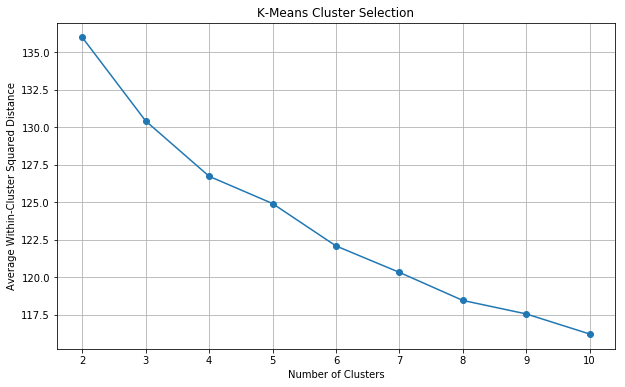

In [36]:
# Investigate the change in within-cluster distance across number of clusters.

completed_clusters = list(cluster_counts)[:len(avg_distances)]

plt.figure(figsize=(10, 6))

plt.plot(
    completed_clusters,
    avg_distances,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Average Within-Cluster Squared Distance')
plt.title('K-Means Cluster Selection')

plt.xticks(completed_clusters)
plt.grid()

plt.show()

In [39]:
# Re-fit the k-means model with the selected number of clusters
# and obtain cluster predictions for the general population.

n_clusters = 6

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=3,
    max_iter=100
)

population_clusters = kmeans.fit_predict(azdias_pca)

print("Number of clusters:", n_clusters)
print("Number of population predictions:", len(population_clusters))

# Display the number of people assigned to each cluster
unique, counts = np.unique(population_clusters, return_counts=True)

for cluster, count in zip(unique, counts):
    print(
        "Cluster",
        cluster,
        ":",
        count,
        "people"
    )

Number of clusters: 6
Number of population predictions: 797426
Cluster 0 : 160820 people
Cluster 1 : 117675 people
Cluster 2 : 196587 people
Cluster 3 : 113049 people
Cluster 4 : 88398 people
Cluster 5 : 120897 people


### Discussion 3.1: Apply Clustering to General Population

<p>
I tested K-means models using cluster counts from 2 through 10 and compared their average within-cluster squared distances. The distance decreased as the number of clusters increased, with the largest improvements occurring among the smaller cluster counts. The rate of improvement began to level off around six clusters.
</p>

<p>
I selected six clusters for the final model. This provided a reasonable balance between reducing within-cluster distance and avoiding additional clusters that produced smaller improvements. The final model assigned all 797,426 population observations to one of the six clusters.
</p>

<p>
The cluster sizes were 160,820 observations in Cluster 0, 117,675 in Cluster 1, 196,587 in Cluster 2, 113,049 in Cluster 3, 88,398 in Cluster 4, and 120,897 in Cluster 5. These assignments will be used to compare the general population with the customer population later in the analysis.
</p>

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [40]:
# Load in the customer demographics data.

customers = pd.read_csv(
    'Udacity_CUSTOMERS_Subset.csv',
    sep=';'
)

print("Original customer data shape:", customers.shape)

Original customer data shape: (191652, 85)


In [45]:
customers_clean = clean_data(customers)

print("Cleaned customer data shape:", customers_clean.shape)

print(
    "Non-numeric columns:",
    customers_clean.select_dtypes(exclude=[np.number]).columns.tolist()
)

Cleaned customer data shape: (141640, 192)
Non-numeric columns: []


In [46]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

# Use the imputer fitted on the general population
customers_array = imputer.transform(customers_clean)
customers_array = customers_array.astype(np.float32, copy=False)

print(
    "Customer NaN values after imputation:",
    np.isnan(customers_array).sum()
)

# Use the scaler fitted on the general population
customers_scaled = scaler.transform(customers_array)
customers_scaled = customers_scaled.astype(np.float32, copy=False)

# Use the PCA model fitted on the general population
customers_pca = pca_final.transform(customers_scaled)
customers_pca = customers_pca.astype(np.float32, copy=False)

# Assign customers to the population clusters
customer_clusters = kmeans.predict(customers_pca)

print("Customer PCA shape:", customers_pca.shape)
print("Number of customer predictions:", len(customer_clusters))

unique, counts = np.unique(
    customer_clusters,
    return_counts=True
)

for cluster, count in zip(unique, counts):
    print(
        "Cluster",
        cluster,
        ":",
        count,
        "customers"
    )

Customer NaN values after imputation: 0
Customer PCA shape: (141640, 80)
Number of customer predictions: 141640
Cluster 0 : 38643 customers
Cluster 1 : 63416 customers
Cluster 2 : 30263 customers
Cluster 3 : 1840 customers
Cluster 4 : 2185 customers
Cluster 5 : 5293 customers


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

   Cluster  Population  Customers  Difference
0        0    0.201674   0.272825    0.071152
1        1    0.147569   0.447727    0.300158
2        2    0.246527   0.213661   -0.032866
3        3    0.141767   0.012991   -0.128777
4        4    0.110854   0.015426   -0.095428
5        5    0.151609   0.037369   -0.114240


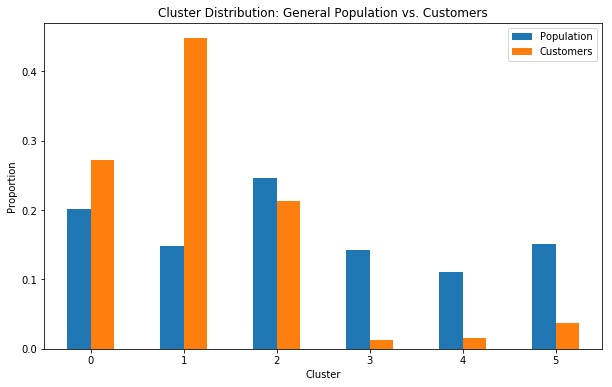

In [47]:
# Compare the proportion of data in each cluster for the customer data
# to the proportion of data in each cluster for the general population.

population_counts = np.bincount(
    population_clusters,
    minlength=6
)

customer_counts = np.bincount(
    customer_clusters,
    minlength=6
)

population_proportions = (
    population_counts / len(population_clusters)
)

customer_proportions = (
    customer_counts / len(customer_clusters)
)

cluster_comparison = pd.DataFrame({
    'Cluster': range(6),
    'Population': population_proportions,
    'Customers': customer_proportions
})

cluster_comparison['Difference'] = (
    cluster_comparison['Customers']
    - cluster_comparison['Population']
)

print(cluster_comparison)

# Plot the proportions
cluster_comparison.plot(
    x='Cluster',
    y=['Population', 'Customers'],
    kind='bar',
    figsize=(10, 6)
)

plt.ylabel('Proportion')
plt.title('Cluster Distribution: General Population vs. Customers')
plt.xticks(rotation=0)
plt.show()

In [48]:
# Investigate the most overrepresented customer cluster.

over_cluster = 1

# Cluster center is currently in PCA space.
cluster_center_pca = kmeans.cluster_centers_[over_cluster].reshape(1, -1)

# Convert from PCA space back to scaled feature space.
cluster_center_scaled = pca_final.inverse_transform(
    cluster_center_pca
)

# Convert from scaled values back to the original feature scale.
cluster_center_original = scaler.inverse_transform(
    cluster_center_scaled
)

# Match values with feature names.
overrepresented_features = pd.Series(
    cluster_center_original[0],
    index=feature_columns
)

print("Cluster 1 - selected demographic characteristics:")
print(
    overrepresented_features[
        [
            'HH_EINKOMMEN_SCORE',
            'CAMEO_WEALTH',
            'FINANZ_MINIMALIST',
            'FINANZ_SPARER',
            'ALTERSKATEGORIE_GROB',
            'PRAEGENDE_DECADE',
            'MOBI_REGIO'
        ]
    ]
)

Cluster 1 - selected demographic characteristics:
HH_EINKOMMEN_SCORE       2.366091
CAMEO_WEALTH             2.022498
FINANZ_MINIMALIST        4.489789
FINANZ_SPARER            1.796371
ALTERSKATEGORIE_GROB     3.224334
PRAEGENDE_DECADE        67.552055
MOBI_REGIO               4.192916
dtype: float32


In [49]:
# Investigate the most underrepresented customer cluster.

under_cluster = 3

# Cluster center is currently in PCA space.
cluster_center_pca = kmeans.cluster_centers_[under_cluster].reshape(1, -1)

# Convert from PCA space back to scaled feature space.
cluster_center_scaled = pca_final.inverse_transform(
    cluster_center_pca
)

# Convert from scaled values back to the original feature scale.
cluster_center_original = scaler.inverse_transform(
    cluster_center_scaled
)

# Match values with feature names.
underrepresented_features = pd.Series(
    cluster_center_original[0],
    index=feature_columns
)

print("Cluster 3 - selected demographic characteristics:")
print(
    underrepresented_features[
        [
            'HH_EINKOMMEN_SCORE',
            'CAMEO_WEALTH',
            'FINANZ_MINIMALIST',
            'FINANZ_SPARER',
            'ALTERSKATEGORIE_GROB',
            'PRAEGENDE_DECADE',
            'MOBI_REGIO'
        ]
    ]
)

Cluster 3 - selected demographic characteristics:
HH_EINKOMMEN_SCORE       5.529084
CAMEO_WEALTH             4.153131
FINANZ_MINIMALIST        1.172098
FINANZ_SPARER            4.372485
ALTERSKATEGORIE_GROB     1.869890
PRAEGENDE_DECADE        85.130058
MOBI_REGIO               1.998402
dtype: float32


### Discussion 3.3: Compare Customer Data to Demographics Data

<p>
The customer cluster distribution differs substantially from the distribution of the general population. Cluster 1 is the most overrepresented group. It contains about 14.76% of the general population but 44.77% of the customer population, a difference of approximately 30 percentage points. Cluster 0 is also overrepresented, containing about 20.17% of the general population and 27.28% of customers.
</p>

<p>
Cluster 1 appears to represent an important customer segment for the mail-order company. The reconstructed cluster center has an HH_EINKOMMEN_SCORE of approximately 2.37, CAMEO_WEALTH of 2.02, FINANZ_MINIMALIST of 4.49, FINANZ_SPARER of 1.80, and ALTERSKATEGORIE_GROB of 3.22. The group therefore tends toward lower wealth and income measures, stronger financial-minimalist characteristics, weaker saving tendencies, and an older age category. The PRAEGENDE_DECADE value of approximately 67.55 also places the center around the 1960s to 1970s generational categories.
</p>

<p>
Cluster 3 is the most underrepresented group. It contains about 14.18% of the general population but only 1.30% of customers. Its reconstructed center shows a very different profile from Cluster 1. HH_EINKOMMEN_SCORE is approximately 5.53 and CAMEO_WEALTH is 4.15, accompanied by a low FINANZ_MINIMALIST value of 1.17 and a high FINANZ_SPARER value of 4.37. ALTERSKATEGORIE_GROB is approximately 1.87 and PRAEGENDE_DECADE is approximately 85.13. This group tends toward higher income and wealth measures, stronger saving tendencies, less financial-minimalist behavior, and a younger age category.
</p>

<p>
These results indicate that the company's customer base is concentrated in particular demographic groups rather than distributed proportionally across the population. Cluster 1 appears to be a strong target segment for the company, whereas Cluster 3 represents a population segment that is much less likely to appear among its customers.
</p>

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.